$\text{Neri Lorenzo 2088285}$

# Esercizio 7:

## Consegna:

Si considerino due modelli probabilistici $M_1$ e $M_2$ per spiegare un dataset $ \mathcal{X} = \mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$,
dove $M_1$ ha parametri $θ_1 ∈ \mathbb{R}^{d_1}$ e $M_2$ ha parametri $θ_2 ∈ \mathbb{R}^{d_2}$ con $d_1 ≪ d_2$.

1. Si trovi un’espressione per l’evidenza $ \log \ p(\mathcal{X}|M)$ (log-verosomiglianza marginale) di un modello $M$ sfruttando l’approssimazione di Laplace, mettendo in evidenza il termine di penalizzazione di complessità (Rasoio di Occam).

2. Si generino dati da
$$
y = 0.5x + \eta \quad \text{con} \ \eta \sim \mathcal{N}(0, 0.1^2) \quad \text{per} \ x \in [−1, 1].
$$
Siano:
$$
\begin{align*}
& M_1 : \quad y = θ_0 + θ_1 x \quad \text{un modello lineare,} \\
& M_2 : \quad y = \sum_{k=0}^{5}{θ_k x^k} \quad \text{un modello polinomiale di grado 5.}
\end{align*}
$$
Scegliendo un’opportuna prior $p(θ)$ e usando l’approssimazione di Laplace, si calcolino le relative evidenze.

3. Si mostri graficamente l’andamento dell’evidenza al crescere di $N$ (da 10 a 1000 punti).

4. Si individui, giustificando teoricamente e numericamente (e.g., graficamente), la regione di Occam ($N^{*}$ dove $M_1$ diviene preferibile).

5. Si discuta come varia il rapporto delle evidenze se $M_2$ ha una prior sparsa (es. Laplace).

## Import dependencies

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

## 1. Log-Evidenza (analitica)  $ \log p(\mathcal{X}|M)$  

- Definizione di Evidenza:
  Dato un modello $M$ con prior $P(\theta | M)$ e likelihood $P(\mathcal{X} | \theta, M)$, l'evidenza marginale è:
  $$
  P(\mathcal{X} | M) = \int_{\mathbb{R}^d} P(\mathcal{X} | \theta, M) \, P(\theta | M) \, d\theta
  $$

- Approssimazione di Laplace:

  Per svolgere questa approssimazione ci serve definire $g(\theta) = \ln \left( P(\mathcal{X} | M, \theta) \, P(\theta | M) \right)$.

  Espandiamo ora $g(\theta)$ tramite Taylor attorno a $\hat{\theta}_{\text{MAP}}$ ottenendo
  $$
  g(\theta) \approx g(\hat{\theta}_{\text{MAP}}) - \frac{1}{2} (\theta - \hat{\theta}_{\text{MAP}})^\top \Sigma^{-1} (\theta - \hat{\theta}_{\text{MAP}})
  \quad \text{con} \
  \Sigma^{-1} := - \left. \frac{\partial^2 g(\theta)}{\partial \theta^2} \right|_{\theta = \hat{\theta}_{\text{MAP}}}
  $$
  che, una volta applicato l'esponenziale, risulta:
  $$
  \exp(g(\theta)) \approx \exp(g(\hat{\theta}_{\text{MAP}})) \cdot \exp\left( -\frac{1}{2} (\theta - \hat{\theta}_{\text{MAP}})^\top \Sigma^{-1} (\theta - \hat{\theta}_{\text{MAP}}) \right)
  \\ \Updownarrow \\
  P(\mathcal{X} | M, \theta) \, P(\theta | M) \approx P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) \, P(\hat{\theta}_{\text{MAP}} ) \cdot \exp\left( -\frac{1}{2} (\theta - \hat{\theta}_{\text{MAP}})^\top \Sigma^{-1} (\theta - \hat{\theta}_{\text{MAP}}) \right).
  $$
  Inserendo ora quest'approssimazione nell'integrale dell'evidenza otteniamo:
  $$
  P(\mathcal{X} | M) \approx P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) \, P(\hat{\theta}_{\text{MAP}} ) \int \exp\left( -\frac{1}{2} (\theta - \hat{\theta}_{\text{MAP}})^\top \Sigma^{-1} (\theta - \hat{\theta}_{\text{MAP}}) \right) d\theta
  $$
  dove $P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) \, P(\hat{\theta}_{\text{MAP}} )$ è fuori dall'integrale inquanto non dipende da $ \theta $.
  

- Calcolo dell’Integrale
  $$
  \begin{align*}
  & \int \exp\left( -\frac{1}{2} (\theta - \hat{\theta}_{\text{MAP}})^\top \Sigma^{-1} (\theta - \hat{\theta}_{\text{MAP}}) \right) d\theta =^{1.)} \\
  & =^{1.)} \int \exp\left( -\frac{1}{2} u^\top \Sigma^{-1} u \right) du =^{2.)} \\
  & =^{2.)} \int \exp\left( -\frac{1}{2} \sum_{i=1}^{d}{\lambda_i z_{i}^{2}} \right) dz = \\
  & = \ \ \ \prod_{i=1}^{d}{ \int \exp\left( -\frac{1}{2} \lambda_i z_{i}^{2} \right)} dz_i = \\
  & = \ \ \ \prod_{i=1}^{d}{(2 \pi)^{\frac{1}{2}} \lambda^{- \frac{1}{2}}_{i} } = (2\pi)^{d/2} |\Sigma|^{1/2}
  \end{align*}
  $$

  1. ) Cambio di variabile: $u = \theta - \hat{\theta}_{\text{MAP}} \Rightarrow d\theta = du$
  2. ) Poiché $\Sigma^{-1}$ è simmetrica definita positiva (SPD), $ \exists Q $ ortogonale t.c. $\Sigma^{-1} = Q \Lambda Q^\top$ con $\Lambda = diag(\lambda_1, ..., \lambda_d )$. Altro cambio di variabile: $z = Q^\top u \Rightarrow u = Qz, du = dz \Rightarrow u^\top \Sigma^{-1} u = z^\top \Lambda z  = \sum_{i=1}^{d}{\lambda_i z_{i}^{2}}$.

Otteniamo infine:
$$
P(\mathcal{X} | M) \approx P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) \, P(\hat{\theta}_{\text{MAP}}) \, (2\pi)^{d/2} |\Sigma|^{1/2}
$$
E il logaritmo:
$$
\ln P(\mathcal{X} | M) \approx \ln P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) + \ln P(\hat{\theta}_{\text{MAP}} ) + \frac{d}{2} \ln(2\pi) + \frac{1}{2} \ln |\Sigma|
$$
con $ \ln P(\mathcal{X} | \hat{\theta}_{\text{MAP}}) $ il best Likelyhood fit e $ \ln P(\hat{\theta}_{\text{MAP}} ) + \frac{d}{2} \ln(2\pi) + \frac{1}{2} \ln |\Sigma| $ il fattore di Occam


### picolo chiarimento

Distinzione tra $\mathcal{X}$, $\mathbf{X}$, e $\mathbf{y}$ nell'approssimazione di Laplace:

Nel contesto bayesiano, l’evidenza di un modello $\mathcal{M}$ è definita come la probabilità del dataset osservato dato il modello:

$$
p(\mathcal{D} \mid \mathcal{M}) = \int p(\mathcal{D} \mid \boldsymbol{\theta}, \mathcal{M}) \, p(\boldsymbol{\theta} \mid \mathcal{M}) \, d\boldsymbol{\theta}
$$

dove $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N$ rappresenta l’intero dataset. Nella notazione matematica compatta, questo viene spesso scritto come:

$$
p(\mathcal{X} \mid \mathcal{M})
$$

dove $\mathcal{X}$ sottintende l'intero insieme dei dati osservati, ovvero sia gli input $\mathbf{X}$ che gli output $\mathbf{y}$.

Tuttavia, nei calcoli pratici, si assume che gli input $\mathbf{X}$ siano **fissati e noti**. Di conseguenza, l’integrale sull’evidenza diventa:

$$
p(\mathbf{y} \mid \mathbf{X}, \mathcal{M}) = \int p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}, \mathcal{M}) \cdot p(\boldsymbol{\theta} \mid \mathcal{M}) \, d\boldsymbol{\theta}
$$

Questa è la forma che viene approssimata tramite l’approssimazione di Laplace, la quale si basa su un’espansione della log-posteriori intorno al punto $\hat{\boldsymbol{\theta}}_{MAP}$.

In particolare, si ottiene:

$$
\log p(\mathbf{y} \mid \mathbf{X}, \mathcal{M}) \approx \log p(\mathbf{y} \mid \mathbf{X}, \hat{\boldsymbol{\theta}}_{MAP}) + \log p(\hat{\boldsymbol{\theta}}_{MAP}) + \frac{d}{2} \log(2\pi) - \frac{1}{2} \log |\Sigma^{-1}|
$$

dove:
- $\log p(\mathbf{y} \mid \mathbf{X}, \hat{\boldsymbol{\theta}}_{MAP})$ è la log-verosimiglianza al MAP,
- $\log p(\hat{\boldsymbol{\theta}}_{MAP})$ è la log-prior,
- $\Sigma^{-1}$ è la matrice Hessiana della log-posteriori negativa.

In sintesi, **l’utilizzo esplicito di $\mathbf{y}$ nei calcoli è corretto**, perché si assume che $\mathbf{X}$ sia nota e costante. L’integrale (e quindi l’approssimazione) riguarda esclusivamente la distribuzione dei **target** condizionata agli input.


## 2. Log-Evidenza (numerica) di $M_1$ ed $M_2$

Procediamo ora a generare i dati tramite $ y = \theta x + \eta \quad $ con $ \theta = 0.5 \in \mathbb{R} ,\  \eta \sim \mathcal{N}(0, 0.1^2) \quad \text{per} \ x ∈ [−1, 1].$

In [ ]:
np.random.seed(42)
a, b = -1, 1
N = 100
sigma_eta = 0.1
mu_eta = 0
x = np.random.uniform(a, b, size=N)
eta = np.random.normal(mu_eta, sigma_eta, size=N)
y = 0.5 * x + eta

Costruiamo i due modelli $M_1$ e $M_2$

In [ ]:
# Design matrices
X_1 = np.vstack([np.ones(N), x]).T           # M1: linear model
X_2 = np.vstack([x**k for k in range(6)]).T  # M2: degree-5 polynomial

Ora bisogna fissare una prior su $\theta$. Una scelta classica è :
$$
p( \theta ) = \mathcal{N}(0,\ \frac{1}{\alpha}\mathbf{I} ), \quad \sigma_{\theta}^2 = \frac{1}{\alpha}.
$$
Fatto ciò, si conosce la forma chiusa di $ \hat{\theta}_{MAP} $ i.e.:
$$
\hat{\theta}_{MAP}
= arg \ max_{\theta } [\log p(y|X,θ) + \log p(θ)]
= ( \lambda \mathbf{I}  +X^{\top} X )^{-1} X^{\top} y \\ \text{con} \
 \lambda := \frac{\sigma_{\eta}^2}{\sigma_{\theta}^2} = \alpha \ \sigma_{\eta}^2
$$

In [ ]:
d_1, d_2 = X_1.shape[1], X_2.shape[1]
alpha = 1 # iperparametro
mu_theta = 0
sigma_theta_sq = 1/alpha
theta = np.random.normal(mu_theta, sigma_theta_sq, size=N)

In [ ]:
A_1 = X_1.T @ X_1 + alpha * sigma_eta**2 * np.eye(d_1)
theta_hat_1 = np.linalg.solve(A_1, X_1.T @ y)

In [ ]:
A_2 = X_2.T @ X_2 + alpha * sigma_eta**2 * np.eye(d_2)
theta_hat_2 = np.linalg.solve(A_2, X_2.T @ y)

Come affermato in precedenza, l'approssimazione di laplace intorno a $ \hat{\theta}_{MAP} $ risulta:
$$
\ln P(y | M) \approx \ln P(y | \hat{\theta}_{\text{MAP}}) + \ln P(\hat{\theta}_{\text{MAP}}) + \frac{d}{2} \ln(2\pi) + \frac{1}{2} \ln |\Sigma|
$$
quindi bisogna calcolarsi i termini uno ad uno:

$$
\begin{align*}
& \cdot \ln P(y |X, \ \hat{\theta}_{\text{MAP}}) = -\frac{N}{2} \log(2\pi \sigma_{\eta}^2) - \frac{1}{2\sigma_{\eta}^2} \| \mathbf{y} - X \hat{\theta}_{\text{MAP}} \|^2 \quad \text{Log-likelyhood al MAP} \\
& \cdot \ln P(\hat{\theta}_{\text{MAP}}) = -\frac{d}{2} \log\left( \frac{2\pi}{\alpha} \right) - \frac{\alpha}{2} \| \hat{\theta}_{\text{MAP}} \|^2 \quad \text{Prior al MAP} \\
& \cdot \frac{d}{2} \ln(2\pi) \\
& \cdot - \frac{1}{2} \ln |\mathbf{H}| \quad \text{Termine di complessità} \quad \text{con} \ \mathbf{H} =\Sigma^{-1} = \frac{1}{\sigma_{\eta}^2} X^\top X + \alpha \mathbf{I} \quad \text{Hessiana (negativa della log-posterior)}
\end{align*}
$$

In [ ]:
# Log-likelihood at MAP
residual_1 = y - X_1 @ theta_hat_1
log_likelihood_1 = -0.5 * N * np.log(2 * np.pi * sigma_eta**2) - 0.5 * np.sum(residual_1**2) / sigma_eta**2

# Log-prior at MAP
log_prior_1 = -0.5 * d_1 * np.log(2 * np.pi / alpha) - 0.5 * alpha * np.sum(theta_hat_1**2)

# Hessian of negative log-posterior
H_1 = (1 / sigma_eta**2) * (X_1.T @ X_1) + alpha * np.eye(d_1)
sign_1, logdet_H_1 = np.linalg.slogdet(H_1)

In [ ]:
# Log-likelihood at MAP
residual_2 = y - X_2 @ theta_hat_2
log_likelihood_2 = -0.5 * N * np.log(2 * np.pi * sigma_eta**2) - 0.5 * np.sum(residual_2**2) / sigma_eta**2

# Log-prior at MAP
log_prior_2 = -0.5 * d_2 * np.log(2 * np.pi / alpha) - 0.5 * alpha * np.sum(theta_hat_2**2)

# Hessian of negative log-posterior
H_2 = (1 / sigma_eta**2) * (X_2.T @ X_2) + alpha * np.eye(d_2)
sign_2, logdet_H_2 = np.linalg.slogdet(H_2)

Infine, mettendo insieme questi valori, possiamo ottenere la nostra log-evidenza per entrambi i modelli

In [ ]:
# Laplace approximation of log-evidence
log_evidence_1 = log_likelihood_1 + log_prior_1 + 0.5 * d_1 * np.log(2 * np.pi) - 0.5 * logdet_H_1

In [ ]:
# Laplace approximation of log-evidence
log_evidence_2 = log_likelihood_2 + log_prior_2 + 0.5 * d_2 * np.log(2 * np.pi) - 0.5 * logdet_H_2

In [ ]:
print(*[theta_hat_1,
       log_likelihood_1,
       log_prior_1,
       logdet_H_1,
       f'Log-Evidenza per M_1 = {log_evidence_1}'],
      sep='\n')

[-0.00148701  0.47687529]
98.03539534801382
-1.951583194367109
17.37255778172696
Log-Evidenza per M_1 = 89.23541032919259


In [ ]:
print(*[theta_hat_2,
       log_likelihood_2,
       log_prior_2,
       logdet_H_2,
       f'Log-Evidenza per M_2 = {log_evidence_2}'],
      sep='\n')

[-0.03310304  0.48162798  0.16826508  0.08164803 -0.12995829 -0.11866296]
100.28956904365764
-5.663136654416854
36.27945361111738
Log-Evidenza per M_2 = 82.00033678291011


Abbiamo ottenuto:

- $\log p(\mathbf{y} \mid \mathcal{M}_1) = 89.23541032919259$
- $\log p(\mathbf{y} \mid \mathcal{M}_2) = 82.00033678291011$

Che vuoldire?
- Il modello $\mathcal{M}_1$ (lineare) ha **evidenza maggiore**, quindi è preferito secondo il criterio bayesiano.
- Sebbene $\mathcal{M}_2$ (polinomiale di grado 5) sia più flessibile, **i dati sono generati da una relazione lineare**, quindi non c'è guadagno sostanziale in termini di fit.
- L'approssimazione di Laplace penalizza modelli complessi attraverso il termine $-\frac{1}{2} \log |\mathbf{H}|$.
- Questa penalità riflette il **principio del Rasoio di Occam**: modelli più complessi vengono sfavoriti se non giustificati dai dati.


## 3. Andamento dell'evidenza al crescere di $N$

Ora, per mostrare graficamente l’andamento dell’evidenza al crescere di $ N $ punti, ci basta ripetere l'esperimento dentro un ciclo for, i.e. $\forall N = 10,...,1000$ .

In [ ]:
#@title Log-Evidences generating function
def generate_log_evidences(N_values, a, b, alpha, sigma_eta, mu_eta):

    log_evidence_M1, log_evidence_M2 = [], [] # To store evidences
    for N in N_values:
        # Generate data
        x = np.random.uniform(a, b, size=N)
        eta = np.random.normal(mu_eta, sigma_eta, size=N)
        y = 0.5 * x + eta

        # Design matrices
        X_1 = np.vstack([np.ones(N), x]).T  # M1: linear model
        X_2 = np.vstack([x**k for k in range(6)]).T  # M2: degree-5 polynomial

        for X, log_evidence_list in zip([X_1, X_2], [log_evidence_M1, log_evidence_M2]):
            d = X.shape[1]

            # Ridge solution (MAP estimate)
            A = X.T @ X + alpha * sigma_eta**2 * np.eye(d)
            theta_hat = np.linalg.solve(A, X.T @ y)

            # Log-likelihood at MAP
            residual = y - X @ theta_hat
            log_likelihood = -0.5 * N * np.log(2 * np.pi * sigma_eta**2) - 0.5 * np.sum(residual**2) / sigma_eta**2

            # Log-prior at MAP
            log_prior = -0.5 * d * np.log(2 * np.pi / alpha) - 0.5 * alpha * np.sum(theta_hat**2)

            # Hessian of negative log-posterior
            H = (1 / sigma_eta**2) * (X.T @ X) + alpha * np.eye(d)
            sign, logdet_H = np.linalg.slogdet(H)

            # Laplace approximation of log-evidence
            log_evidence = log_likelihood + log_prior + 0.5 * d * np.log(2 * np.pi) - 0.5 * logdet_H
            log_evidence_list.append(log_evidence)

    return log_evidence_M1, log_evidence_M2

In [ ]:
#@title Plotting functions
def plot_log_evidences(N_values, log_evidence_M1, log_evidence_M2):
    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, log_evidence_M1, label="Modello M1 (lineare)", marker="o")
    plt.plot(N_values, log_evidence_M2, label="Modello M2 (polinomiale 5°)", marker="x")
    plt.xlabel("Numero di dati N")
    plt.ylabel("Log-evidenza")
    plt.title("Confronto dell'evidenza tra M1 e M2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.xticks(np.arange(0, 1001, 100))
    plt.show()

def plot_log_evidence_diff(N_values, log_evidence_M1, log_evidence_M2):
    log_evidence_diff = [log_evidence_M1[i]-log_evidence_M2[i] for i in range(len(log_evidence_M1))]
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, log_evidence_diff, label="log_evidence_M1 - log_evidence_M2", marker="o")
    plt.xlabel("Numero di dati N")
    plt.ylabel("log_evidence_M1 - log_evidence_M2")
    plt.title("differenza dell'evidenza tra M1 e M2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.xticks(np.arange(0, 1001, 100))
    plt.show()

def plot_evidence_rate(N_values, log_evidence_M1, log_evidence_M2):
    log_evidence_diff = [log_evidence_M1[i]-log_evidence_M2[i] for i in range(len(log_evidence_M1))]
    plt.figure(figsize=(10, 6))
    plt.plot(N_values, log_evidence_diff, label="evidence_M1 / evidence_M2", marker="o")
    plt.xlabel("Numero di dati N")
    plt.ylabel("log_evidence_M1-log_evidence_M2")
    plt.title("rapporto tra l'evidenza M1 e M2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.axhline(-10, color='green', linestyle='--', linewidth=1)
    plt.yticks(np.arange(-20, 20, 5))
    plt.xticks(np.arange(0, 1001, 100))
    plt.show()

In [ ]:
# ricordiamo:
np.random.seed(42)
a, b = -1, 1

alpha = 1 # iperparametro

sigma_eta = 0.1
mu_eta = 0

mu_theta = 0
sigma_theta_sq = 1/alpha
N_values = np.arange(10, 1001, 10) # From 10 to 1000

In [ ]:
log_evidence_M1, log_evidence_M2 = generate_log_evidences(N_values,
                                                          a, b,
                                                          alpha,
                                                          sigma_eta,
                                                          mu_eta
                                                          )

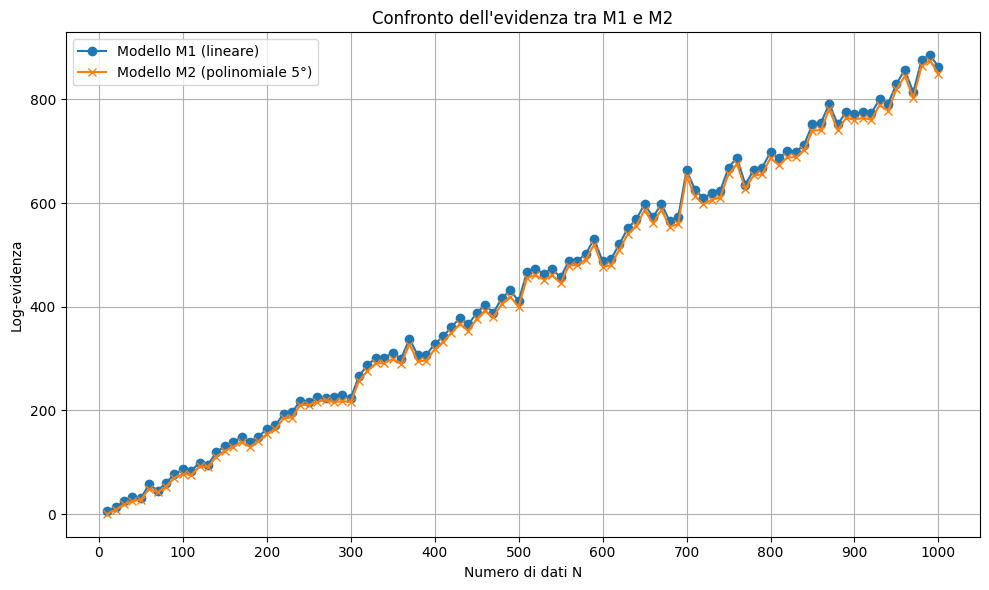

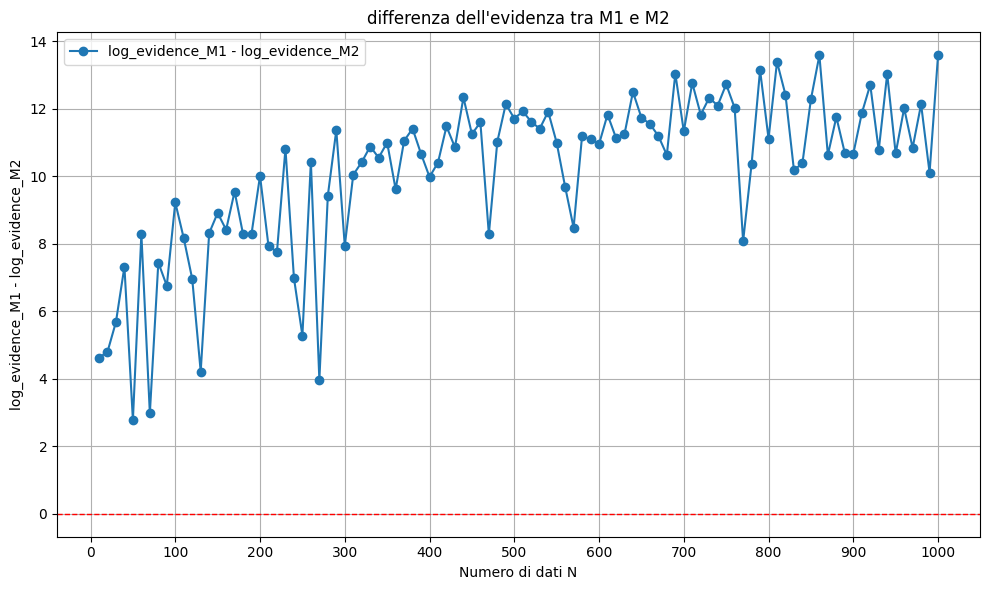

In [ ]:
plot_log_evidences(N_values, log_evidence_M1, log_evidence_M2)
plot_log_evidence_diff(N_values, log_evidence_M1, log_evidence_M2)

Da questi grafici notiamo che la Log-Evidenza procede linearmente all'aumentare del numero di dati; inoltre plottando la differenza $ \log p(\mathbf{y} \mid \mathcal{M}_1) - \log p(\mathbf{y} \mid \mathcal{M}_2) $ notiamo che questa quantità non scende mai sotto lo zero, indicando quindi che il modello $M_1$ viene considerato sempre migliore secondo il criterio bayesiano... perche?

Il punto chiave sta nella scelta della prior $p(\theta)$, in particolare della varianza $\sigma_{\theta}^2 = \frac{1}{\alpha}$, infatti, con $N$ fissato, aumentando l'iperparametro $\alpha$ diminuiamo il determinante di $\Sigma$ che di conseguenza contribuisce di meno all'approssimazione.

Estendiamo queste considerazioni nel punto 4.

## 4. Regione di Occam ($N^*$ dove $M_1$ diviene preferibile).

Proviamo quindi a ripetere l'esperimento ma aumentando significativamente l'iperparametro $\alpha$ e.g. $\alpha$ = 200

In [ ]:
# ricordiamo:
np.random.seed(42)
a, b = -1, 1

alpha = 200 # iperparametro

sigma_eta = 0.1
mu_eta = 0

mu_theta = 0
sigma_theta_sq = 1/alpha
N_values = np.arange(10, 1001, 10) # From 10 to 1000

In [ ]:
log_evidence_M1, log_evidence_M2 = generate_log_evidences(N_values,
                                                          a, b,
                                                          alpha,
                                                          sigma_eta,
                                                          mu_eta
                                                          )

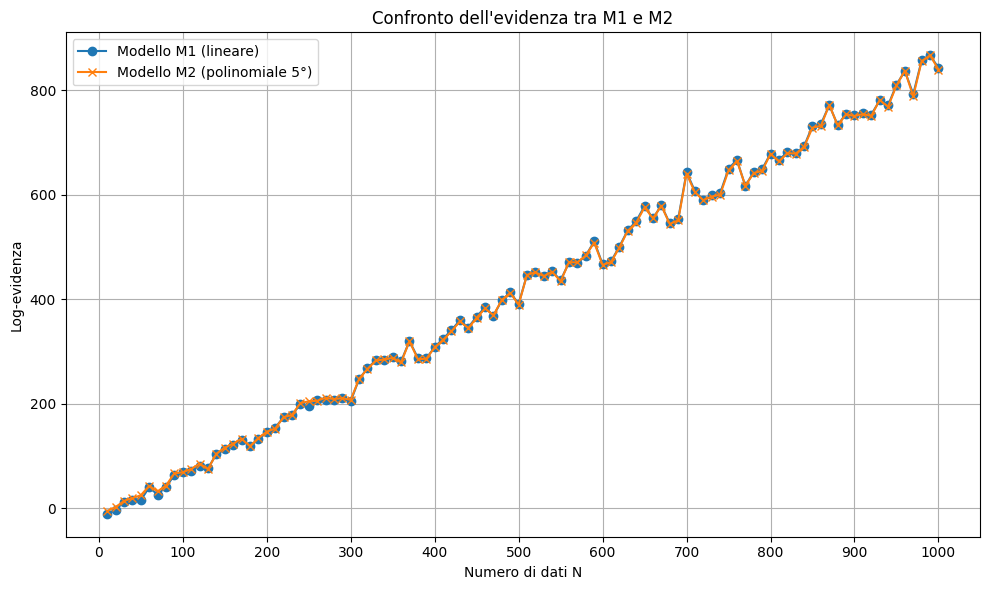

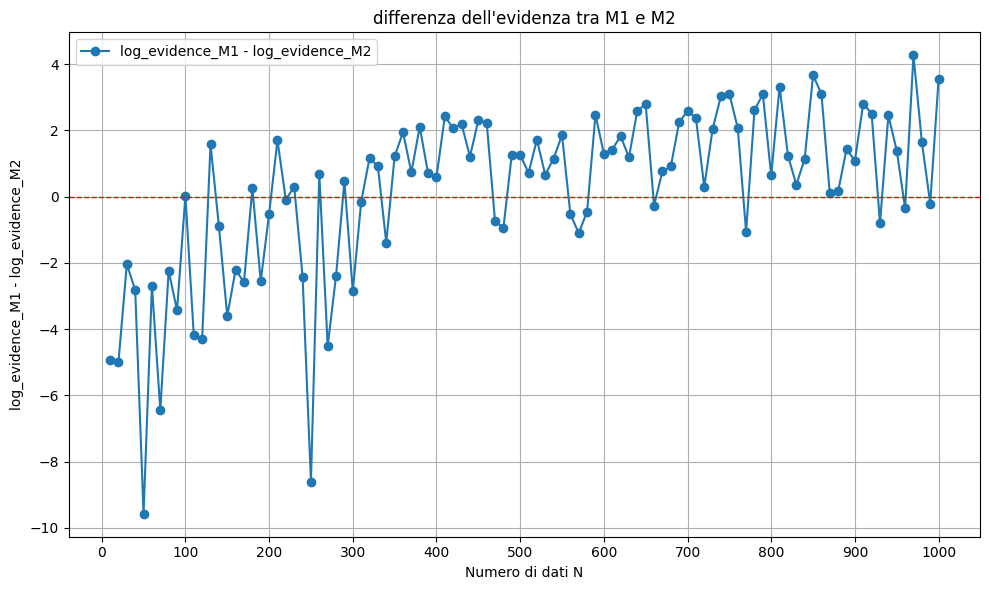

In [ ]:
plot_log_evidences(N_values, log_evidence_M1, log_evidence_M2)
plot_log_evidence_diff(N_values, log_evidence_M1, log_evidence_M2)

**Spiegazione teorica:** perché $\mathcal{M}_2$ è preferito per piccoli $N$ con $\alpha = 200$

Abbiamo osservato che con $\alpha = 200$ (prior molto stretta) il termine $\frac{d}{2} \ln(2\pi)$ domina rispetto a $ \frac{1}{2} \ln |\Sigma|$, quindi il modello più complesso $\mathcal{M}_2$ ha log-evidenza maggiore rispetto a $\mathcal{M}_1$ per $N \lesssim 350$. Più nel dettaglio,
una prior con alta precisione penalizza i parametri lontani da 0. Tuttavia, $\mathcal{M}_2$ può ancora sfruttare combinazioni di termini (es. $x^2$, $x^3$, ecc.) per adattarsi ai dati anche con una prior stretta.
Inoltre:

- **Pochi dati = fit più facile**  
    Con pochi dati, il modello complesso $\mathcal{M}_2$ riesce a overfittare in modo efficace → ottiene una log-verosimiglianza più alta.

- **Penalizzazione di Occam non ancora dominante**  
    La penalità $\frac{1}{2} \log|\mathbf{H}|$ (volume dello spazio dei parametri) è ancora limitata per piccoli $N$, infatti, dato che $\mathbf{H} = \frac{1}{\sigma_{\eta}^2} X^\top X + \alpha \mathbf{I}$, aumentando $N$ aumento il "peso" di $X^\top X$, incrementando quindi il valore di $| \mathbf{H} |$, che, con segno negativo nell'approssimazione, diminuisce la log-evidenza.


Al dilà della teoria, dal grafico possiamo individuare $N^* \simeq 350 $ e quindi per $N \ge N^* $ vale $ \log p(\mathbf{y} \mid \mathcal{M}_1) \gtrsim \log p(\mathbf{y} \mid \mathcal{M}_2) $

Possiamo spingerci oltre? cosa succede per altri valori di $\alpha$ ?

In [ ]:
#@title generating-evidence grid function definition
def gen_diff_log_evidence_grid(alpha_values, N_values, a, b, sigma_eta, mu_eta):
    # Compute log-evidence difference for each (N, alpha)
    for i, alpha in enumerate(alpha_values):
        log_evidence_M1, log_evidence_M2 = generate_log_evidences(
            N_values, a, b, alpha, sigma_eta, mu_eta
        )
        diff_log_evidence_grid[i, :] = np.array(log_evidence_M1) - np.array(log_evidence_M2)
    return diff_log_evidence_grid

In [ ]:
#@title 3D plotting evidence function definition
def plot_3d_diff_log_evidence(N_grid,alpha_grid,diff_log_evidence_grid,cmap, yaxis_title='Alpha (precisione prior)'):
    fig = go.Figure(data=[go.Surface(
        x=N_grid,
        y=alpha_grid,
        z=diff_log_evidence_grid,
        colorscale=cmap,
        colorbar=dict(title='M1 - M2')
            )])

    fig.update_layout(
        title='Differenza log-evidenza (M1 - M2)',
        scene=dict(
            xaxis_title='Numero di dati N',
            yaxis_title=yaxis_title,
            zaxis_title='Differenza log-evidenza'
        ),
        width=1000,
        height=600,
        margin=dict(l=0, r=0, b=0, t=50)
    )
    fig.show()

In [ ]:
#@title cmaps
cmaps = {0: 'aggrnyl', 1: 'agsunset', 2: 'algae', 3: 'amp', 4: 'armyrose', 5: 'balance',
         6: 'blackbody', 7: 'bluered', 8: 'blues', 9: 'blugrn', 10: 'bluyl',
         11: 'brbg', 12: 'brwnyl', 13: 'bugn', 14: 'bupu', 15: 'burg',
         16: 'burgyl', 17: 'cividis', 18: 'curl', 19: 'darkmint', 20: 'deep',
         21: 'delta', 22: 'dense', 23: 'earth', 24: 'edge', 25: 'electric',
         26: 'emrld', 27: 'fall', 28: 'geyser', 29: 'gnbu', 30: 'gray',
         31: 'greens', 32: 'greys', 33: 'haline', 34: 'hot', 35: 'hsv',
         36: 'ice', 37: 'icefire', 38: 'inferno', 39: 'jet', 40: 'magenta',
         41: 'magma', 42: 'matter', 43: 'mint', 44: 'mrybm', 45: 'mygbm',
         46: 'oranges', 47: 'orrd', 48: 'oryel', 49: 'oxy', 50: 'peach',
         51: 'phase', 52: 'picnic', 53: 'pinkyl', 54: 'piyg', 55: 'plasma',
         56: 'plotly3', 57: 'portland', 58: 'prgn', 59: 'pubu', 60: 'pubugn',
         61: 'puor', 62: 'purd', 63: 'purp', 64: 'purples', 65: 'purpor',
         66: 'rainbow', 67: 'rdbu', 68: 'rdgy', 69: 'rdpu', 70: 'rdylbu',
         71: 'rdylgn', 72: 'redor', 73: 'reds', 74: 'solar', 75: 'spectral',
         76: 'speed', 77: 'sunset', 78: 'sunsetdark', 79: 'teal', 80: 'tealgrn',
         81: 'tealrose', 82: 'tempo', 83: 'temps', 84: 'thermal', 85: 'tropic',
         86: 'turbid', 87: 'turbo', 88: 'twilight', 89: 'viridis', 90: 'ylgn',
         91: 'ylgnbu', 92: 'ylorbr', 93: 'ylorrd'}

In [ ]:
# Define the ranges
N_values = np.arange(100, 1001, 50)
alpha_values = np.linspace(0.1, 500, 100)

# Create meshgrid for 3D plotting
N_grid, alpha_grid = np.meshgrid(N_values, alpha_values)
diff_log_evidence_grid = np.zeros_like(N_grid)
cmap = cmaps[37]

In [ ]:
diff_log_evidence_grid = gen_diff_log_evidence_grid(alpha_values, N_values, a, b, sigma_eta, mu_eta)
plot_3d_diff_log_evidence(N_grid,alpha_grid,diff_log_evidence_grid,cmap)

Notiamo quindi che quando la prior non è molto precisa, cioè ha una varianza alta, ci conviene usare $M_1$ in quanto risulta piu robusto. (c'è un iperpiano $ z = \log p(\mathbf{y}, \alpha \mid \mathcal{M}_1) -  \log p(\mathbf{y}, \alpha \mid \mathcal{M}_2) = 0 $ che funziona da threshold per capire se una coppia $ (\alpha_i, N_j) $ permette al modello $M_1$ di performare meglio del modello $M_2$.)

## 5. Rapporto delle evidenze se $M_2$ ha prior sparsa

A questo punto non ci resta che considerare il caso in cui $M_2$ ha una prior sparsa, in particolare vediamo il caso di prior di Laplace, cioè:
$$
p(\theta \mid M_2) = \prod_{k=1}^{d_2} \frac{\lambda}{2} \exp(-\lambda |\theta_k|) = \left( \frac{\lambda}{2} \right)^{d_2} \exp\left( -\lambda \|\theta\|_1 \right) \quad \text{con } \theta \in \mathbb{R}^{d_2}.
$$
Perchè una tale scelta? Una prior sparsa favorisce soluzioni in cui molti parametri sono esattamente zero; infatti, la Laplaciana, o double exponential, è più "aggressiva" della Gaussiana nel forzare i parametri piccoli a zero a causa della norma 1.

La log-prior è ovviamente:
$$
\log p(\theta \mid M_2) = -\lambda \|\theta\|_1 + d_2 \log ( \lambda /2 )
$$

- Con prior Gaussiana (Ridge), tutti i parametri sono attivi → $M_2$ viene penalizzato di più.
- Con prior Laplace (LASSO = Least Absolute Shrinkage and Selection Operator), la posteriori spinge molti $\theta_k$ a zero → il modello complesso diventa effettivamente più semplice.
- Quindi: la penalità di complessità è più bassa, e $M_2$ può competere meglio con $M_1$.

Detto ciò, ora procediamo per capire cosa dobbiamo cambiare per adattarci a questa nuova distribuzione

Prima di tutto, dato che dobbbiamo usare l'approssimazione di Laplace, dobbiamo stimare MAP con prior Laplace:

 - Come abbiamo gia visto, la stima MAP, si ottiene massimizzando la log-posterior:
  $$
  \hat{\theta}_{MAP} = \arg\max_\theta \left[ \log p(y \mid X, \theta) + \log p(\theta) \right]
  $$
  la quale è composta dai seguenti termini:
  - Likelihood:  
  $$
  \log p(y \mid X, \theta) = -\frac{1}{2\sigma^2} \|y - X\theta\|_2^2 + \text{costante}
  $$
  - Prior Laplace:  
  $$
  \log p(\theta) = -\lambda \|\theta\|_1 + \text{costante}
  $$

  Quindi, il problema MAP equivale a risolvere:
  $$
  \hat{\theta}_{MAP} = \arg\min_\theta [ g(\theta) ]
  \quad \text{con} \ g(\theta) = \frac{1}{2\sigma^2} \|y - X\theta\|_2^2 + \lambda \|\theta\|_1
  $$

  Questo è esattamente il problema di Lasso regression.

Problema: Come troviamo effettivamente la stima MAP? grazie alle assunzioni gaussiane per la prior avevamo una forma chiusa per $\hat{\theta}_{MAP}$ ma ora non è piu possibile inquanto $|| \cdot ||_1$ non è differenziabile in zero. Per fortuna ci sono molti metodi di ottimizzazione iterativa per minimizzare $g(\theta)$, quello che useremo noi è Coordinate Descent


**Coordinate Descent:**
- $X \in \mathbb{R}^{n \times d}$: matrice dei dati  
- $y \in \mathbb{R}^n$: vettore dei target  
- $\lambda > 0$: parametro di regolarizzazione  
- $\theta \gets \mathbf{0} = (0,...,0)^{\top}$  
- Pre-calcola $\|X_j\|_2^2 = \sum_{i=1}^n X_{ij}^2$ per ogni $j$
- Per ogni iterazione fino a convergenza:
  - Per ogni coordinata $j = 1, \dots, d$:

    1. Calcola la predizione corrente:

      $
      \hat{y} = X \theta
      $

    2. Calcola il residuo parziale escludendo la variabile $j$:

      $
      r_j = y - \hat{y} + X_j \theta_j
      $

    3. Calcola la correlazione parziale:

      $
      \rho_j = X_j^\top r_j = \sum_{i=1}^n X_{ij} \cdot r_{j,i}
      $

    4. Aggiorna il coefficiente $\theta_j$ usando la **soft-thresholding function**:

      $
      \theta_j \gets S\left( \frac{\rho_j}{\|X_j\|_2^2}, \frac{\lambda}{\|X_j\|_2^2} \right)
      $

      con $S(a, b)$ la funzione di soft-thresholding definita come:

  $$
  S(a, b) =
  \begin{cases}
  a - b & \text{se } a > b \\
  0     & \text{se } |a| \leq b \\
  a + b & \text{se } a < -b
  \end{cases}
  $$

  - Criterio di arresto:

    Ferma l'algoritmo se
    $
    ||\theta^{(t)} - \theta^{(t-1)}||_p < \varepsilon
    $

    dove $\varepsilon$ è una soglia di tolleranza.

Se l'algoritmo si ferma dopo $T$ passi con $\theta^{(T)}$ la stima trovata al passo $T$-esimo, allora $\theta^{(T)}$ è la nostra stima stima $\theta_{\text{MAP}}$ sotto prior di Laplace.

Ora basta con la teoria, sporchiamoci un po le mani!

In [ ]:
#@title new functions, Laplace-prior-helpers

def soft_threshold(a, b):
    return np.sign(a) * np.maximum(np.abs(a) - b, 0.0)

def lasso_coordinate_descent(X, y, lam, max_iter=1000, tol=1e-4):
    n, d = X.shape
    theta = np.zeros(d)
    X_norms = np.sum(X**2, axis=0)

    for iteration in range(max_iter):
        theta_old = theta.copy()
        for j in range(d):
            # Calcola il residuo r_j
            y_pred = X @ theta
            rho_j = X[:, j] @ (y - y_pred + X[:, j] * theta[j])

            # Aggiorna con soft-thresholding
            theta[j] = soft_threshold(rho_j / X_norms[j], lam / X_norms[j])

        # Controllo della convergenza
        if np.linalg.norm(theta - theta_old, ord=1) < tol:
            break

    return theta

In [ ]:
#@title Gaussian and Laplacian priors and MAPs
# Funzioni di calcolo log-prior e MAP estimate per prior gaussiana e laplace

def compute_gaussian_prior(theta_hat, alpha):
    d = len(theta_hat)
    log_prior = -0.5 * d * np.log(2 * np.pi / alpha) - 0.5 * alpha * np.sum(theta_hat**2)
    return log_prior

def compute_laplace_prior(theta_hat, lam):
    d = len(theta_hat)
    log_prior = -lam * np.sum(np.abs(theta_hat)) + d * np.log(lam / 2)
    return log_prior

def solve_map_gaussian(X, y, sigma_eta, alpha):
    d = X.shape[1]
    A = X.T @ X + alpha * sigma_eta**2 * np.eye(d)
    theta_hat = np.linalg.solve(A, X.T @ y)
    return theta_hat

def solve_map_laplace(X, y, lam):
    return lasso_coordinate_descent(X, y, lam)

In [ ]:
#@title new Log-Evidences generating function
# Funzione principale aggiornata
def generate_log_evidences_flexible(
    N_values, a, b,
    sigma_eta, mu_eta,
    alpha,               lam,
    prior_M1='gaussian', prior_M2='gaussian'
):
    log_evidence_M1, log_evidence_M2 = [], []

    for N in N_values:
        x = np.random.uniform(a, b, size=N)
        eta = np.random.normal(mu_eta, sigma_eta, size=N)
        y = 0.5 * x + eta

        X_1 = np.vstack([np.ones(N), x]).T
        X_2 = np.vstack([x**k for k in range(6)]).T

        for X, prior_type, log_list in zip([X_1, X_2], [prior_M1, prior_M2], [log_evidence_M1, log_evidence_M2]):
            d = X.shape[1]

            # MAP estimate
            if prior_type == 'gaussian':
                theta_hat = solve_map_gaussian(X, y, sigma_eta, alpha)
                log_prior = compute_gaussian_prior(theta_hat, alpha)
            elif prior_type == 'laplace':
                theta_hat = solve_map_laplace(X, y, lam)
                log_prior = compute_laplace_prior(theta_hat, lam)
            else:
                raise ValueError("Prior type must be 'gaussian' or 'laplace'")
            print(theta)
            # Log-likelihood
            residual = y - X @ theta_hat
            log_likelihood = -0.5 * N * np.log(2 * np.pi * sigma_eta**2) - 0.5 * np.sum(residual**2) / sigma_eta**2

            # Hessian approximation
            H = (1 / sigma_eta**2) * (X.T @ X)
            _, logdet_H = np.linalg.slogdet(H + 1e-6 * np.eye(d))

            # Log-evidenza
            log_evidence = log_likelihood + log_prior + 0.5 * d * np.log(2 * np.pi) - 0.5 * logdet_H
            log_list.append(log_evidence)


    return log_evidence_M1, log_evidence_M2

In [ ]:
# ricordiamo

np.random.seed(42)
a, b = -1, 1                  # Intervallo per generare feature
alpha = 200                   # Iperparametro prior

sigma_eta = 0.1               # Deviazione standard del rumore
mu_eta = 0                    # Media del rumore

sigma_theta_sq = 1 / alpha    # Varianza prior gaussiana
mu_theta = 0                  # Media della prior su theta

lam = 2                       # Parametro prior Laplace

N_values = np.arange(10, 1001, 10)

In [ ]:
log_evidence_M1g, log_evidence_M2l = generate_log_evidences_flexible(

    N_values=N_values,
    a=a, b=b,
    sigma_eta=sigma_eta, mu_eta=mu_eta,
    alpha=alpha,         lam=lam,
    prior_M1='gaussian', prior_M2='laplace'
)
print(min([e1-e2 for e1,e2 in zip(log_evidence_M1g, log_evidence_M2l) ]))

[ 0.01300189  1.45353408 -0.26465683  2.72016917  0.62566735 -0.85715756
 -1.0708925   0.48247242 -0.22346279  0.71400049  0.47323762 -0.07282891
 -0.84679372 -1.51484722 -0.44651495  0.85639879  0.21409374 -1.24573878
  0.17318093  0.38531738 -0.88385744  0.15372511  0.05820872 -1.1429703
  0.35778736  0.56078453  1.08305124  1.05380205 -1.37766937 -0.93782504
  0.51503527  0.51378595  0.51504769  3.85273149  0.57089051  1.13556564
  0.95400176  0.65139125 -0.31526924  0.75896922 -0.77282521 -0.23681861
 -0.48536355  0.08187414  2.31465857 -1.86726519  0.68626019 -1.61271587
 -0.47193187  1.0889506   0.06428002 -1.07774478 -0.71530371  0.67959775
 -0.73036663  0.21645859  0.04557184 -0.65160035  2.14394409  0.63391902
 -2.02514259  0.18645431 -0.66178646  0.85243333 -0.79252074 -0.11473644
  0.50498728  0.86575519 -1.20029641 -0.33450124 -0.47494531 -0.65332923
  1.76545424  0.40498171 -1.26088395  0.91786195  2.1221562   1.03246526
 -1.51936997 -0.48423407  1.26691115 -0.70766947  0.

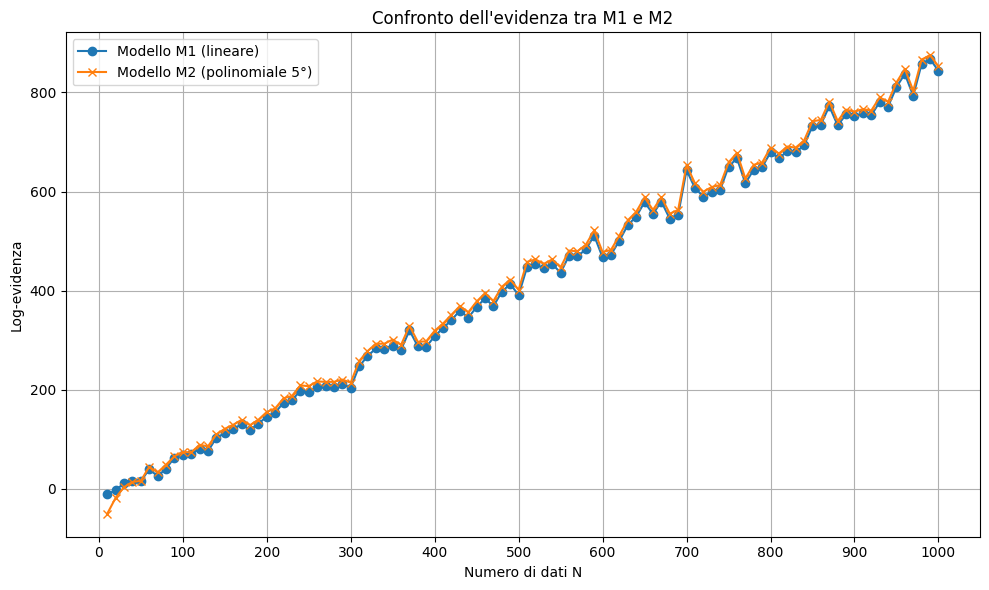

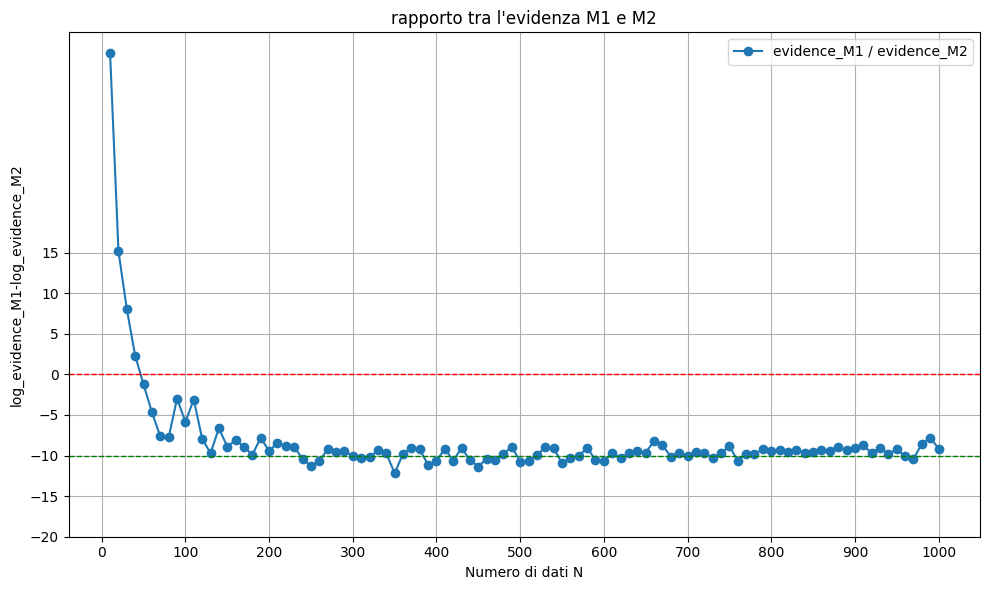

In [ ]:
plot_log_evidences(N_values, log_evidence_M1g, log_evidence_M2l)
plot_evidence_rate(N_values, log_evidence_M1g, log_evidence_M2l)

Grazie a questo cambio di approccio sulla prior di $M_2$, fissati $ \alpha = 200, \lambda = 2 $, abbiamo ottenuto miglioramenti significativi sulla bontà del modello, nonostante il modello gaussiano lineare sia effettivamente il modello esatto.

Vediamo ora in generale cosa succede per vari valori di $\alpha $ e $\lambda$:

In [ ]:
#@title grid generating function with ```generate_log_evidences_flexible``` function (lambda fixed)
def gen_diff_log_evidence_grid1(alpha_values, N_values, a, b, sigma_eta, mu_eta, lam = 2):

    diff_log_evidence_grid = np.zeros((alpha_values.shape[0],N_values.shape[0]))

    # Compute log-evidence difference for each (N, alpha)
    for i, alpha in enumerate(alpha_values):
        log_evidence_M1, log_evidence_M2 = generate_log_evidences_flexible(
                                            N_values=N_values,
                                            a=a, b=b,
                                            sigma_eta=sigma_eta, mu_eta=mu_eta,
                                            alpha=alpha,         lam=lam,
                                            prior_M1='gaussian', prior_M2='laplace')
        diff_log_evidence_grid[i, :] = np.array(log_evidence_M1) - np.array(log_evidence_M2)
    return diff_log_evidence_grid

In [ ]:
np.random.seed(42)
a, b = -1, 1                  # Intervallo per generare feature

sigma_eta = 0.1               # Deviazione standard del rumore
mu_eta = 0                    # Media del rumore

sigma_theta_sq = 1 / alpha    # Varianza prior gaussiana
mu_theta = 0                  # Media della prior su theta

lam = 2                       # Parametro prior Laplace

# Define the ranges
N_values = np.arange(100, 1001, 50)
alpha_values = np.linspace(0.01, 500, 100)

# Create meshgrid for 3D plotting
N_grid, alpha_grid = np.meshgrid(N_values, alpha_values)
diff_log_evidence_grid1 = np.zeros_like(N_grid)
cmap = cmaps[37]

In [ ]:
diff_log_evidence_grid1 = gen_diff_log_evidence_grid1(alpha_values, N_values, a, b, sigma_eta, mu_eta, lam)
plot_3d_diff_log_evidence(N_grid,alpha_grid,diff_log_evidence_grid1,cmap)

Output streaming troncato alle ultime 5000 righe.
  1.6324113  -1.43014138 -0.44004449  0.13074058  1.44127329 -1.43586215
  1.16316375  0.01023306 -0.98150865  0.46210347]
[ 0.01300189  1.45353408 -0.26465683  2.72016917  0.62566735 -0.85715756
 -1.0708925   0.48247242 -0.22346279  0.71400049  0.47323762 -0.07282891
 -0.84679372 -1.51484722 -0.44651495  0.85639879  0.21409374 -1.24573878
  0.17318093  0.38531738 -0.88385744  0.15372511  0.05820872 -1.1429703
  0.35778736  0.56078453  1.08305124  1.05380205 -1.37766937 -0.93782504
  0.51503527  0.51378595  0.51504769  3.85273149  0.57089051  1.13556564
  0.95400176  0.65139125 -0.31526924  0.75896922 -0.77282521 -0.23681861
 -0.48536355  0.08187414  2.31465857 -1.86726519  0.68626019 -1.61271587
 -0.47193187  1.0889506   0.06428002 -1.07774478 -0.71530371  0.67959775
 -0.73036663  0.21645859  0.04557184 -0.65160035  2.14394409  0.63391902
 -2.02514259  0.18645431 -0.66178646  0.85243333 -0.79252074 -0.11473644
  0.50498728  0.86575519 

Possiamo notare dal plot che: avendo fissato $\lambda = 2$ il modello di Laplace è nettamente superiore a quello gaussiano ad eccezione di $\alpha < 100 .$
Per questa ragione ora proviamo a fissare $\alpha = 100 $ per visualizzare come cambia il rapporto delle evidenze al variare dell'iperparametro $\lambda$.

In [ ]:
# Define the ranges
N_values = np.arange(100, 1001, 100)
lambda_values = np.linspace(0.01, 1000, 200)

# Create meshgrid for 3D plotting
N_grid, alpha_grid = np.meshgrid(N_values, lambda_values)
diff_log_evidence_grid1 = np.zeros_like(N_grid)

In [ ]:
#@title grid generating function with ```generate_log_evidences_flexible``` function (alpha fixed)
def gen_diff_log_evidence_grid2(lambda_values, N_values, a, b, sigma_eta, mu_eta, alpha = 100):

    diff_log_evidence_grid = np.zeros((lambda_values.shape[0],N_values.shape[0]))

    # Compute log-evidence difference for each (N, alpha)
    for i, lam in enumerate(lambda_values):
        log_evidence_M1, log_evidence_M2 = generate_log_evidences_flexible(
                                            N_values=N_values,
                                            a=a, b=b,
                                            sigma_eta=sigma_eta, mu_eta=mu_eta,
                                            alpha=alpha,         lam=lam,
                                            prior_M1='gaussian', prior_M2='laplace')
        diff_log_evidence_grid[i, :] = np.array(log_evidence_M1) - np.array(log_evidence_M2)
    return diff_log_evidence_grid

In [ ]:
np.random.seed(42)
a, b = -1, 1                  # Intervallo per generare feature
alpha = 200                   # Iperparametro prior

sigma_eta = 0.1               # Deviazione standard del rumore
mu_eta = 0                    # Media del rumore

sigma_theta_sq = 1 / alpha    # Varianza prior gaussiana
mu_theta = 0                  # Media della prior su theta

# Define the ranges
N_values = np.arange(100, 1001, 50)
lambda_values1 = np.linspace(0.01, 100, 200)

# Create meshgrid for 3D plotting
N_grid, lambda_grid1 = np.meshgrid(N_values, lambda_values1)
diff_log_evidence_grid2 = np.zeros_like(N_grid)
cmap = cmaps[37]

In [ ]:
diff_log_evidence_grid2 = gen_diff_log_evidence_grid2(lambda_values1, N_values, a, b, sigma_eta, mu_eta, alpha)
plot_3d_diff_log_evidence(N_grid,lambda_grid1,diff_log_evidence_grid2,cmap,yaxis_title='lambda (penalizzazione)')

Output streaming troncato alle ultime 5000 righe.
  1.6324113  -1.43014138 -0.44004449  0.13074058  1.44127329 -1.43586215
  1.16316375  0.01023306 -0.98150865  0.46210347]
[ 0.01300189  1.45353408 -0.26465683  2.72016917  0.62566735 -0.85715756
 -1.0708925   0.48247242 -0.22346279  0.71400049  0.47323762 -0.07282891
 -0.84679372 -1.51484722 -0.44651495  0.85639879  0.21409374 -1.24573878
  0.17318093  0.38531738 -0.88385744  0.15372511  0.05820872 -1.1429703
  0.35778736  0.56078453  1.08305124  1.05380205 -1.37766937 -0.93782504
  0.51503527  0.51378595  0.51504769  3.85273149  0.57089051  1.13556564
  0.95400176  0.65139125 -0.31526924  0.75896922 -0.77282521 -0.23681861
 -0.48536355  0.08187414  2.31465857 -1.86726519  0.68626019 -1.61271587
 -0.47193187  1.0889506   0.06428002 -1.07774478 -0.71530371  0.67959775
 -0.73036663  0.21645859  0.04557184 -0.65160035  2.14394409  0.63391902
 -2.02514259  0.18645431 -0.66178646  0.85243333 -0.79252074 -0.11473644
  0.50498728  0.86575519 

Figo eh? peccato che ci interessano solo i valori di $\lambda$ in cui il rapporto delle evidenze è intorno a zero, quindi bisogna usare un intervallo piu piccolo.

In [ ]:
lambda_values2 = np.linspace(0.01, 10, 200)
N_grid, lambda_grid2 = np.meshgrid(N_values, lambda_values2)
diff_log_evidence_grid2 = np.zeros_like(N_grid)
diff_log_evidence_grid2 = gen_diff_log_evidence_grid2(lambda_values2, N_values, a, b, sigma_eta, mu_eta, alpha)
plot_3d_diff_log_evidence(N_grid,lambda_grid2,diff_log_evidence_grid2,cmap,yaxis_title='lambda (penalizzazione)')

Output streaming troncato alle ultime 5000 righe.
  1.6324113  -1.43014138 -0.44004449  0.13074058  1.44127329 -1.43586215
  1.16316375  0.01023306 -0.98150865  0.46210347]
[ 0.01300189  1.45353408 -0.26465683  2.72016917  0.62566735 -0.85715756
 -1.0708925   0.48247242 -0.22346279  0.71400049  0.47323762 -0.07282891
 -0.84679372 -1.51484722 -0.44651495  0.85639879  0.21409374 -1.24573878
  0.17318093  0.38531738 -0.88385744  0.15372511  0.05820872 -1.1429703
  0.35778736  0.56078453  1.08305124  1.05380205 -1.37766937 -0.93782504
  0.51503527  0.51378595  0.51504769  3.85273149  0.57089051  1.13556564
  0.95400176  0.65139125 -0.31526924  0.75896922 -0.77282521 -0.23681861
 -0.48536355  0.08187414  2.31465857 -1.86726519  0.68626019 -1.61271587
 -0.47193187  1.0889506   0.06428002 -1.07774478 -0.71530371  0.67959775
 -0.73036663  0.21645859  0.04557184 -0.65160035  2.14394409  0.63391902
 -2.02514259  0.18645431 -0.66178646  0.85243333 -0.79252074 -0.11473644
  0.50498728  0.86575519 

Per finire, il plot evidenzia come con pochi dati la scelta di lambda è critica per costruire un modello polinomiale laplaciano più o meno comparabile a quello lineare gaussiano, mentre, nel caso di molti dati, la discrepanza di qualità tende a diminuire, favorendo anzi il modello laplaciano.